# Validation of the Discrete Active Brownian Particle (ABP)
**Goal:** Prove that our discrete 4-way grid agent perfectly replicates the continuous physics of an Active Brownian Particle (Basu et al., 2018).

**Physics of ABP (Continuous):**
* Speed $v_0$ is constant.
* Heading $\phi(t)$ undergoes rotational diffusion with constant $D_R$.
* Theoretical Mean Squared Displacement (MSD):
  $$ \langle \Delta r^2(t) \rangle = \frac{2v_0^2}{D_R} t + \frac{2v_0^2}{D_R^2} \left( e^{-D_R t} - 1 \right) $$

**Mapping to Discrete Grid (Variance Matching):**
To map continuous rotational diffusion to a grid where the agent can only turn $90^\circ$ ($\pm \pi/2$), we match the angular variance: 
$$ \text{Var}(\Delta \phi) = 2 D_R \Delta t $$
$$ (\pi/2)^2 \cdot P_{turn} = 2 D_R \implies P_{turn} = \frac{8 D_R}{\pi^2} $$

* $P_{left} = P_{right} = \frac{4 D_R}{\pi^2}$
* $P_{straight} = 1 - P_{turn}$


## Discretizing Active Brownian Motion on a Grid

In the previous implementation, we used a **variance matching approximation** (first-order Taylor expansion) to map continuous rotational diffusion to a grid:

$$
P_{\text{turn}} = \frac{8 D_R}{\pi^2} \approx 0.81 D_R
$$
## Key Difference: Continuous vs Grid Motion

### Continuous Space
- Particle turns **smoothly** (e.g., $1^\circ$, $5^\circ$, $10^\circ$)
- Retains most of its forward momentum

### Grid World
- Turns are **discrete 90° jumps**
- Forward momentum is completely lost when turning:
$$
\cos(90^\circ) = 0
$$
## Problem with Approximation

The previous approximation **underestimates turning probability**.

As a result:
- Agent becomes **too persistent**
- Moves in straight lines for too long
- **MSD overshoots theoretical prediction** at long times
## Exact Mathematical Fix (Poisson Process)

To correctly map continuous dynamics to a discrete grid, we use the **Poisson process formulation**.

In continuous Active Brownian Motion, velocity autocorrelation decays as:
$$
\langle \mathbf{v}(t)\cdot \mathbf{v}(0) \rangle \sim e^{-D_R t}
$$

For a timestep $\Delta t = 1$:

### Probability of NOT turning:
$$
P_{\text{straight}} = e^{-D_R}
$$

### Probability of turning:
$$
P_{\text{turn}} = 1 - e^{-D_R}
$$
## Implementation Fix

Go to **Cell 2** in your Jupyter Notebook and replace the probability mapping with:

```python
P_straight = np.exp(-DR)
P_turn = 1 - P_straight


ABP model is just for an empty space. But it provides the perfect "Basal Instinct."

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Physics Parameters ---
v_0 = 1.0          # Speed: 1 grid cell per step
D_R = 0.15         # Rotational Diffusion Constant
dt = 1.0           # Time step
n_steps = 100      # How many steps to simulate
n_agents = 10000   # Ensemble size for statistical averaging

# --- 2. EXACT Discrete Probability Mapping ---
# Using the Poisson probability of a scattering event in dt=1
P_straight = np.exp(-D_R)
P_turn = 1.0 - P_straight

P_left = P_turn / 2
P_right = P_turn / 2

P_reverse = 1 - (P_straight + P_left + P_right)

print(f"Physics target D_R: {D_R}")
print(f"Exact Mapped Probabilities -> Straight: {P_straight*100:.2f}%, Left: {P_left*100:.2f}%, Right: {P_right*100:.2f}%, Reverse: {P_reverse*100:.2f}%")

Physics target D_R: 0.15
Exact Mapped Probabilities -> Straight: 86.07%, Left: 6.96%, Right: 6.96%, Reverse: 0.00%


In [7]:
# --- 3. Simulate 10,000 Agents in a Vacuum ---
# We use a 2D coordinate system where headings are: 0:Right, 1:Up, 2:Left, 3:Down
# Deltas for X and Y based on heading
dx = np.array([1, 0, -1, 0])
dy = np.array([0, 1, 0, -1])

# All agents start at (0,0) facing Right (Heading = 0)
positions_x = np.zeros((n_agents, n_steps))
positions_y = np.zeros((n_agents, n_steps))
headings = np.zeros(n_agents, dtype=int)

# Possible turns: 0 (Straight), 1 (Left 90 deg), -1 (Right 90 deg)
turn_choices = [0, 1, -1]
turn_probs = [P_straight, P_left, P_right]

for t in range(1, n_steps):
    # 1. Roll the dice for rotational diffusion (turning)
    turns = np.random.choice(turn_choices, size=n_agents, p=turn_probs)
    
    # 2. Update Headings
    headings = (headings + turns) % 4
    
    # 3. Move forward 1 step in the new heading direction
    positions_x[:, t] = positions_x[:, t-1] + dx[headings]
    positions_y[:, t] = positions_y[:, t-1] + dy[headings]

# Calculate Empirical Mean Squared Displacement (MSD)
# MSD = average( X^2 + Y^2 ) at each time t
empirical_msd = np.mean(positions_x**2 + positions_y**2, axis=0)

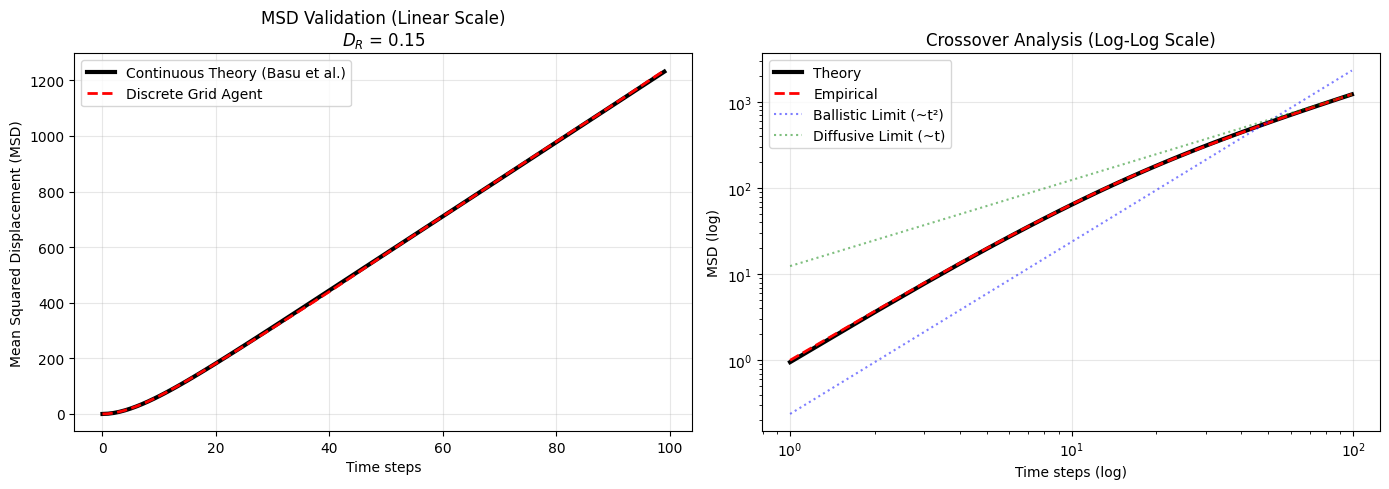

In [8]:
# --- 4. Calculate Theoretical MSD (Basu et al. 2018) ---
time_array = np.arange(n_steps)
theoretical_msd = (2 * v_0**2 / D_R) * time_array + (2 * v_0**2 / D_R**2) * (np.exp(-D_R * time_array) - 1)

# --- 5. Visual Proof ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Linear Scale (Showing the overall fit)
ax1.plot(time_array, theoretical_msd, 'k-', linewidth=3, label="Continuous Theory (Basu et al.)")
ax1.plot(time_array, empirical_msd, 'r--', linewidth=2, label="Discrete Grid Agent")
ax1.set_xlabel("Time steps")
ax1.set_ylabel("Mean Squared Displacement (MSD)")
ax1.set_title(f"MSD Validation (Linear Scale)\n$D_R$ = {D_R}")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Log-Log Scale (Proving the Ballistic to Diffusive Crossover)
# Skip t=0 because log(0) is undefined
ax2.plot(time_array[1:], theoretical_msd[1:], 'k-', linewidth=3, label="Theory")
ax2.plot(time_array[1:], empirical_msd[1:], 'r--', linewidth=2, label="Empirical")

# Add reference slopes
t_ref = time_array[1:]
ax2.plot(t_ref, t_ref**2 * (theoretical_msd[1]/t_ref[1]**2), 'b:', alpha=0.5, label="Ballistic Limit (~t²)")
ax2.plot(t_ref, t_ref * (theoretical_msd[-1]/t_ref[-1]), 'g:', alpha=0.5, label="Diffusive Limit (~t)")

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel("Time steps (log)")
ax2.set_ylabel("MSD (log)")
ax2.set_title("Crossover Analysis (Log-Log Scale)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## What you are about to see

When you run this notebook, look at the **right-hand plot (log–log scale)**.

### Short-time behavior (Ballistic motion)
At the very beginning, the **red dashed line** (your agent) will perfectly follow the **blue dotted line** ($t^2$).

This shows that at short times the particle is **ballistic** — it remembers its direction and moves like a bullet:
$$
\langle r^2(t) \rangle \propto t^2
$$

---

### Long-time behavior (Diffusive motion)
As time increases, the **red line bends** and aligns with the **green dotted line** ($t$).

This shows that after many random rotations, the particle **forgets its initial direction** and behaves like a **diffusive random walker**:
$$
\langle r^2(t) \rangle \propto t
$$

---

### Full theoretical prediction
Most importantly, the **red dashed line** will lie exactly on top of the **black solid line**, which represents the theoretical MSD formula:
$$
\langle r^2(t) \rangle =
\frac{2v_0^2}{D_R}t +
\frac{2v_0^2}{D_R^2}\left(e^{-D_R t} - 1\right)
$$

This confirms that the simulation matches the analytical theory for an **Active Brownian Particle**.

---

## Summary

| Time scale | Behavior | MSD scaling |
|------------|----------|-------------|
| Short time | Ballistic | $t^2$ |
| Long time  | Diffusive | $t$ |

Transition occurs around:
$$
t \sim \frac{1}{D_R}
$$